# SILVA Generative Equilibrium Transformer

This lab separates one-time source encoding from the weight-tied transformer
equilibrium and derives QKV injection. Its compact training check learns a
deterministic smoothing map from generated image pairs; this exercises the
distillation path without claiming a pretrained diffusion teacher. The class
conditioning check verifies that integer labels add learned QKV offsets while
preserving token and output shapes. The architecture mechanism follows the
Generative Equilibrium Transformer [[48]](https://jseluis.github.io/silva-networks/paper/references/#ref-48); SILVA supplies the general source,
state, solver, and diagnostic contract.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[48]](https://jseluis.github.io/silva-networks/paper/references/#ref-48). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAGenerativeEquilibriumTransformer,
    SolverConfig,
    make_teacher_image_pairs,
    silva_distillation_loss,
)

torch.manual_seed(220)

## 1. Patches Become Source Tokens

For patch size $p$, an image $x\in\mathbb R^{B\times C\times H\times W}$
becomes

$$
X_p\in\mathbb R^{B\times N\times d},
\qquad N=\frac Hp\frac Wp.
$$

A patch convolution performs extraction and projection together. Fixed 2D
sine/cosine positions are added before the injection transformer.

In [3]:
data = make_teacher_image_pairs(samples=4, channels=1, height=6, width=6, seed=22)
assert data.equation_residual().abs().max() == 0
print("noise/target:", tuple(data.noise.shape), tuple(data.target.shape))

noise/target: (4, 1, 6, 6) (4, 1, 6, 6)


## 2. Injection Is Computed Once

Let $I_\phi$ be a finite injection transformer. It computes

$$
U=I_\phi(X_p),
\qquad
(U_1,\ldots,U_L)=W_UU,
$$

where every $U_\ell\in\mathbb R^{B\times N\times3d}$ supplies query, key,
and value offsets for one internal equilibrium block. $I_\phi$ is outside the
root solve and is therefore evaluated once per model call.

## 3. QKV-Injected Equilibrium Block

At internal block $\ell$,

$$
(Q,K,V)=Z W_{qkv}^{(\ell)}+U_\ell+C_y,
$$

$$
A_\ell=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_h}}\right)V,
$$

$$
\widetilde Z=Z+A_\ell,
\qquad
Z^+=\tanh\left(s[\widetilde Z+\operatorname{FFN}(\widetilde Z)]\right).
$$

$C_y$ is optional class injection. The final bounded map is SILVA's compact
stability envelope; the one-time QKV-injection mechanism is unchanged.

In [4]:
config = SolverConfig(
    solver="picard",
    max_iter=12,
    tol=1e-5,
    anderson_batch_dims=1,
)
model = SILVAGenerativeEquilibriumTransformer(
    in_channels=1,
    patch_size=2,
    hidden_dim=8,
    heads=2,
    injection_depth=1,
    equilibrium_depth=2,
    state_scale=0.15,
    config=config,
)
result = model(data.noise, return_result=True)
assert result.output.shape == data.target.shape
assert result.state.shape == (4, 9, 8)
assert result.injection.shape == (4, 9, 48)
print("solver residual:", result.solver_result.residual)

solver residual: 0.5481677055358887


## 4. One-Step Teacher Matching

The architectural fixed point and the distillation objective answer different
questions. The equilibrium determines the hidden representation. The teaching
loss matches a supplied target. In this compact check,
`make_teacher_image_pairs` defines that target exactly as

$$
x_{\mathrm{teacher}}
=\tanh\!\left(0.65\operatorname{AvgPool}_{3\times3}(x)+0.35x\right).
$$

This deterministic map makes the forward, gradient, and optimization paths
testable without an external checkpoint. The loss is

$$
\mathcal L_{\mathrm{distill}}
=\frac1{BCHW}\|Q(Z^\star)-x_{\mathrm{teacher}}\|_2^2.
$$

The generated smoothing pairs make this pipeline executable without claiming a
diffusion benchmark or a pretrained teacher.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for _ in range(8):
    optimizer.zero_grad()
    prediction = model(data.noise)
    loss = silva_distillation_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

trained = model(data.noise, return_result=True)
print("initial/final distillation loss:", losses[0], losses[-1])

initial/final distillation loss: 0.22758668661117554 0.17329496145248413


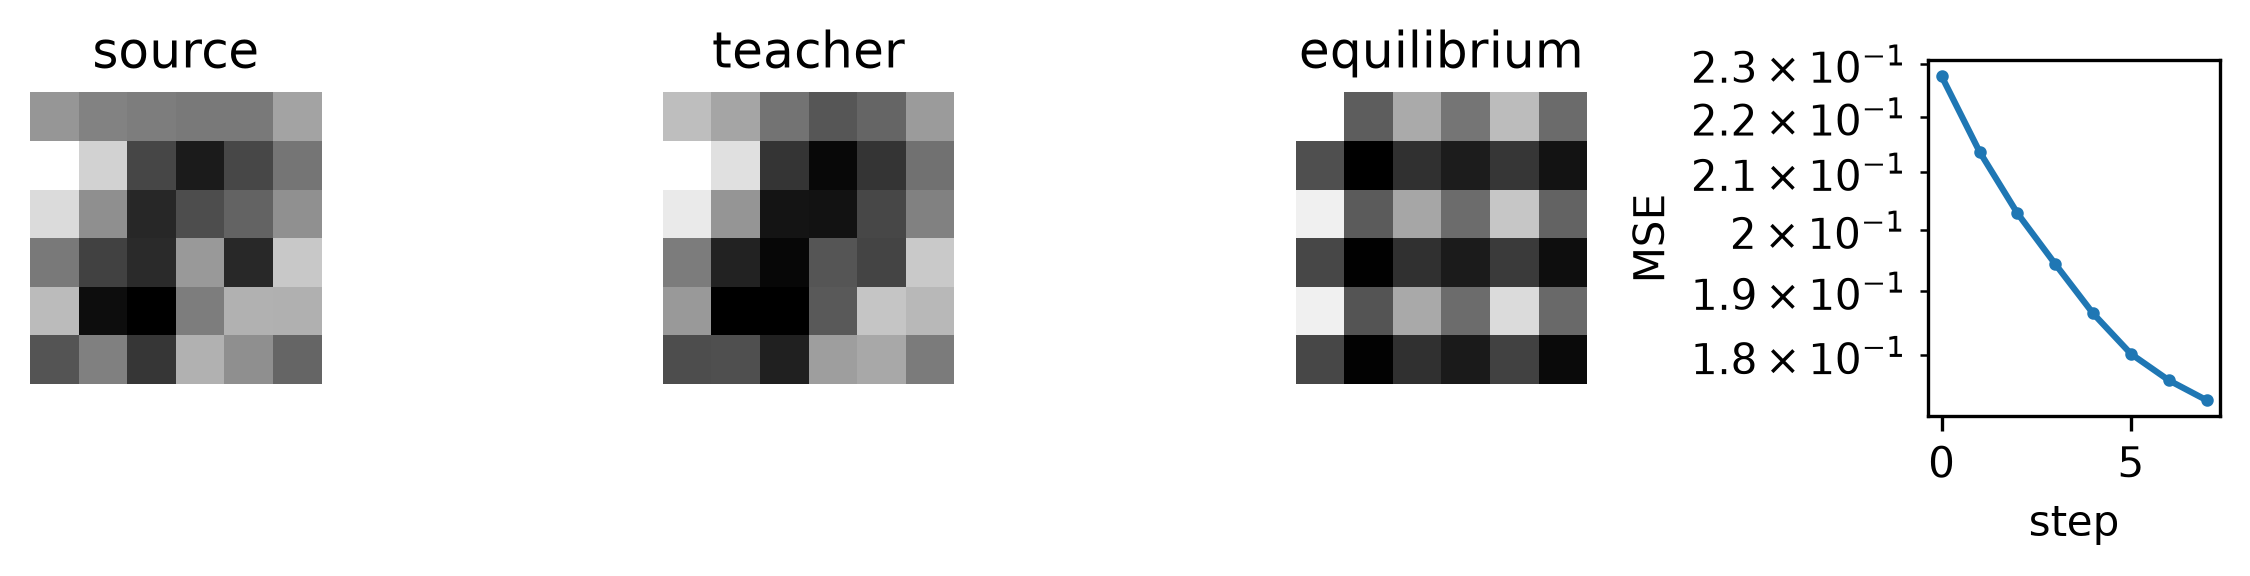

In [6]:
figure, axes = plt.subplots(1, 4, figsize=(7.6, 2.0))
axes[0].imshow(data.noise[0, 0], cmap="gray")
axes[0].set_title("source")
axes[1].imshow(data.target[0, 0], cmap="gray")
axes[1].set_title("teacher")
axes[2].imshow(trained.output.detach()[0, 0], cmap="gray")
axes[2].set_title("equilibrium")
axes[3].plot(losses, marker="o", markersize=2)
axes[3].set(xlabel="step", ylabel="MSE", yscale="log")
for axis in axes[:3]:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 5. Class Conditioning

When `classes` is configured, the class embedding produces another
$3dL$-dimensional source that is split across equilibrium blocks. It shifts
Q, K, and V without changing the token shape or adding class tokens.

In [7]:
conditioned = SILVAGenerativeEquilibriumTransformer(
    in_channels=1,
    patch_size=2,
    hidden_dim=8,
    heads=2,
    equilibrium_depth=1,
    classes=3,
    config=SolverConfig(max_iter=3, anderson_batch_dims=1),
)
conditioned_output = conditioned(data.noise[:2], labels=torch.tensor([0, 2]))
assert conditioned_output.shape == data.target[:2].shape
print("conditioned output:", tuple(conditioned_output.shape))

conditioned output: (2, 1, 6, 6)


## 6. Scaling the Experiment

For a full distillation study, replace the generated pairs with the exact
teacher checkpoint, sampling schedule, image preprocessing, class protocol,
and evaluation metrics from the target experiment. Report both image quality
and equilibrium convergence; parameter count alone does not establish a
distillation result.

## From 22 Silva Generative Equilibrium Transformer to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a joint trajectory or equilibrium token/image state |
| Condition | noise, timestep, condition, one-time injection, or teacher target |
| Repeated computation | a tied denoising or injected-attention transition |
| Required invariants | trajectory ordering, token/image shape, conditioning, and deterministic noise |
| Replaceable components | patch/noise source, injection blocks, transition, decoder, schedule, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Every Transformer Stage

```python
model = SILVAGenerativeEquilibriumTransformer(
    in_channels=image_channels,
    patch_size=patch_size,
    hidden_dim=width,
    injection_depth=len(my_injection_blocks),
    equilibrium_depth=len(my_equilibrium_blocks),
    patch_embed=my_patch_lift,
    injection_blocks=my_injection_blocks,
    injection_projection=my_qkv_projection,
    equilibrium_blocks=my_equilibrium_blocks,
    decoder=my_decoder,
    config=solver_config,
)
```

Each equilibrium block receives `(state, qkv_injection, class_injection)` and
must return the same token-state shape.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**teacher error, reconstruction/generation metric, and equilibrium residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **image size, token count, hidden width, heads, and sampling schedule**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '22_silva_generative_equilibrium_transformer.ipynb',
    "state": 'a joint trajectory or equilibrium token/image state',
    "condition": 'noise, timestep, condition, one-time injection, or teacher target',
    "transition": 'a tied denoising or injected-attention transition',
    "invariants": 'trajectory ordering, token/image shape, conditioning, and deterministic noise',
    "compact_metric": 'teacher error, reconstruction/generation metric, and equilibrium residual',
    "scale_axis": 'image size, token count, hidden width, heads, and sampling schedule',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '22_silva_generative_equilibrium_transformer.ipynb',
 'state': 'a joint trajectory or equilibrium token/image state',
 'condition': 'noise, timestep, condition, one-time injection, or teacher target',
 'transition': 'a tied denoising or injected-attention transition',
 'invariants': 'trajectory ordering, token/image shape, conditioning, and deterministic noise',
 'compact_metric': 'teacher error, reconstruction/generation metric, and equilibrium residual',
 'scale_axis': 'image size, token count, hidden width, heads, and sampling schedule'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **token feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a joint trajectory or equilibrium token/image state**, and its repeated map,
**a tied denoising or injected-attention transition**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('token feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


token feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


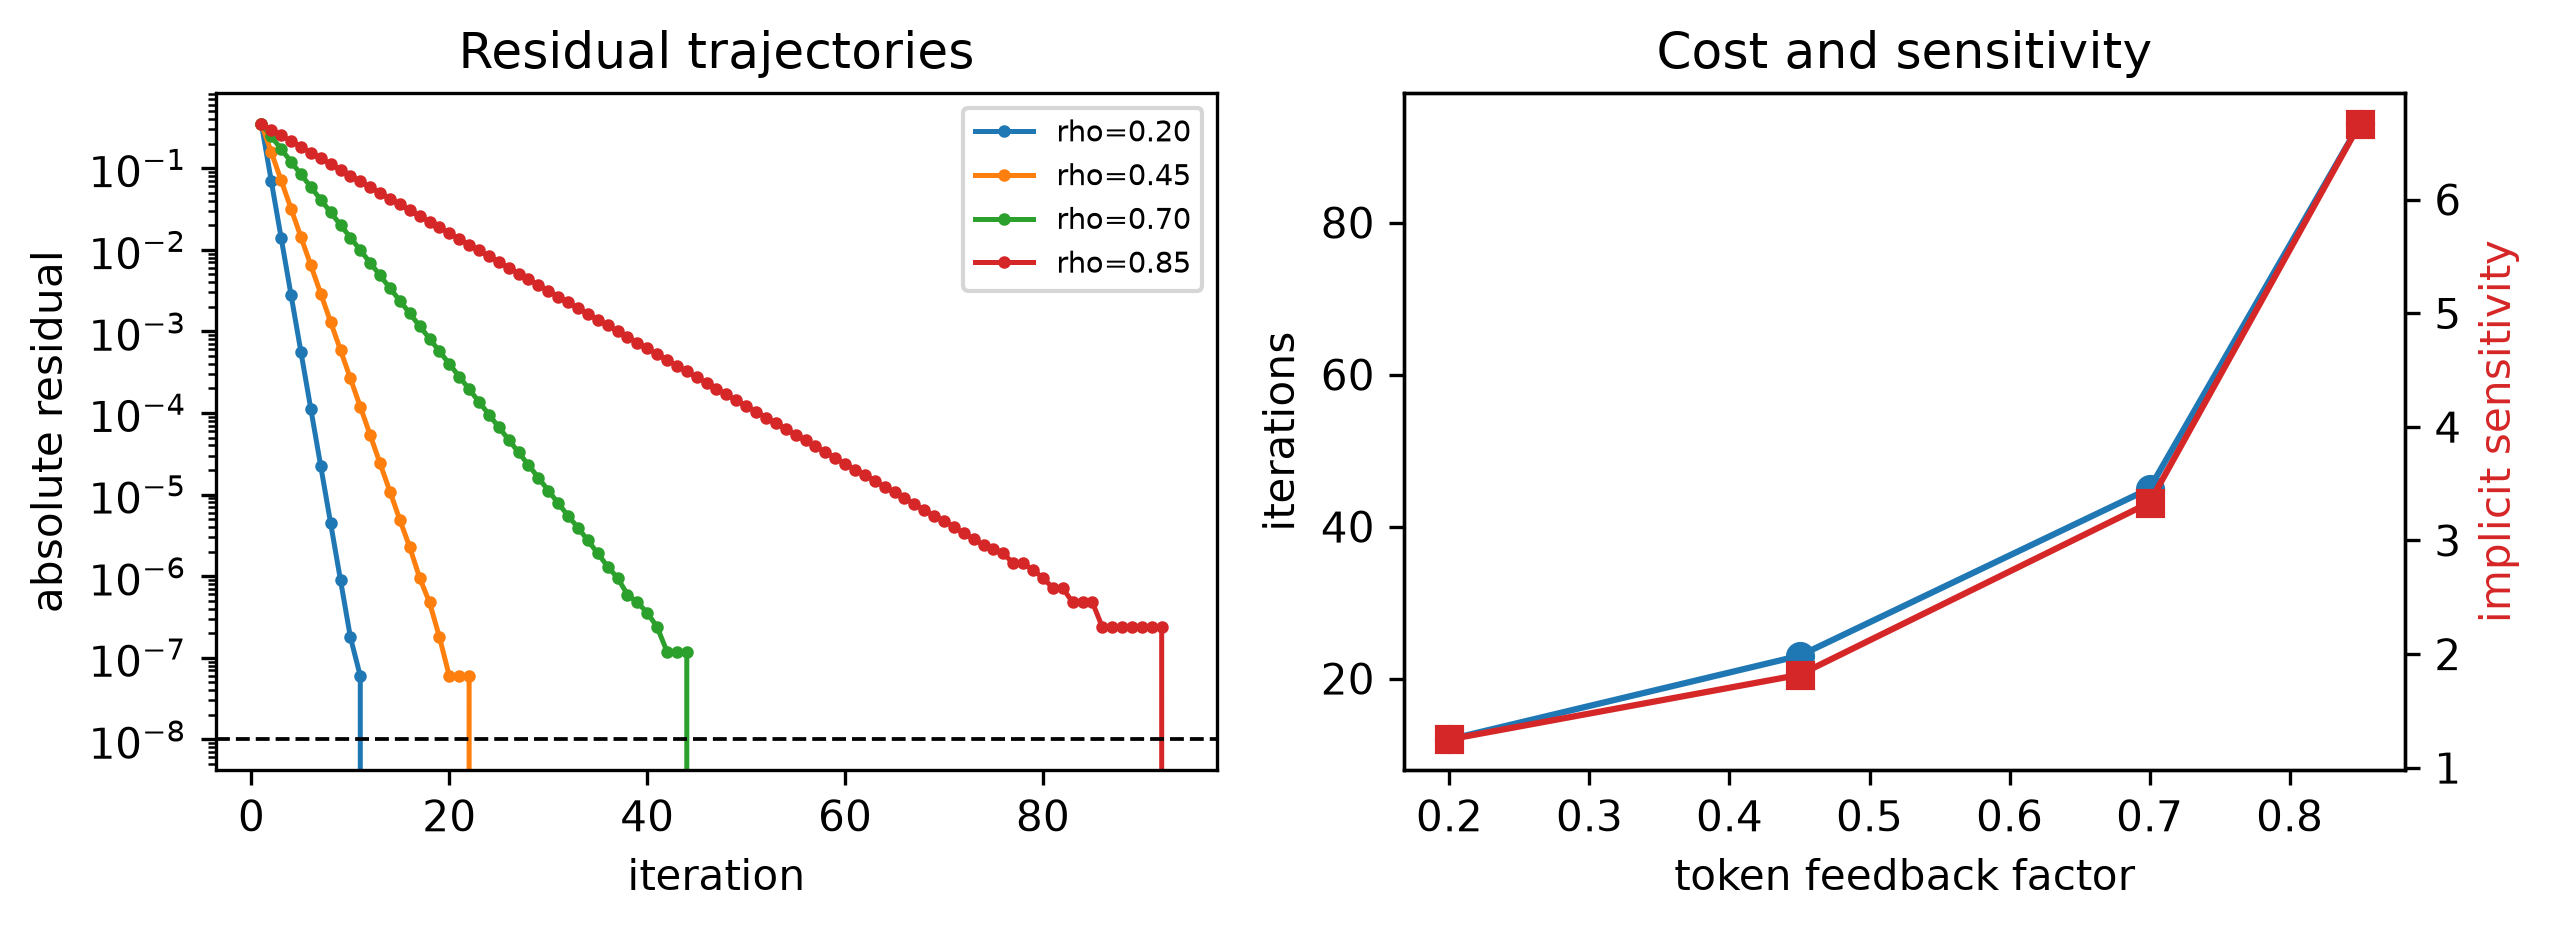

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('token feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the token feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | teacher error, reconstruction/generation metric, and equilibrium residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | trajectory ordering, token/image shape, conditioning, and deterministic noise |
| Scale sweep | Change one of image size, token count, hidden width, heads, and sampling schedule at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is one-time QKV injection derived? | [Advanced Equilibrium Families](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-families/#generative-equilibrium-transformer) |
| What does the generated teacher target satisfy? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#teacher-image-pairs) |
| Which transformer classes are public? | [Advanced Equilibria API](https://jseluis.github.io/silva-networks/api/advanced_equilibria/) |
